# MOLTIE – Prework Cell (Y Summary + JSONL Flatten)

## Purpose

This notebook cell performs **two prep steps** before deeper Moltie analysis:

1. **Summarise `Y_inferred.json`**: which WS rows produced a valid `Y` and which `X` tests were emitted.
2. **Flatten `MASTER_moltie.jsonl`** into tabular form and build a **PDF hit frequency** view.

It then saves both flattened outputs as CSVs next to the master JSONL file.

---

## Inputs

### Files

* `Y_inferred.json`

  * Path: `/home/hello/Projects/Statements/output/Y_inferred.json`
  * Expected to contain a `rows` object keyed by `y_row_id`.

* `MASTER_moltie.jsonl`

  * Path: `/home/hello/Projects/Statements/output/moltie_batch/MASTER_moltie.jsonl`

* `flatter.py`

  * Dir: `/home/hello/Projects/Statements/code/data_analysis`
  * Must export:

    * `flatten_moltie_jsonl(jsonl_path)`
    * `pdf_hit_frequency_view(df_flat)`

### Python deps

* `pandas`

---

## What it Produces

### 1) `y_summary_df`

A per-WS-row summary table:

* `y_row_id`: key from `Y_inferred.json: rows`
* `row_index_1based`: 1-based WS row index
* `y_ok`: whether inference succeeded for that row
* `n_x_tests`: number of `X*` tests emitted (only if `y_ok=True`)
* `x_keys`: list of X test keys (e.g. `['X5', 'X12']`)

Also prints:

* total Y rows
* count of `y_ok` vs `y_fail`

### 2) `df_flat`

Flattened table output from `MASTER_moltie.jsonl` (schema defined by `flatter.py`).

### 3) `df_pdf_freq`

Aggregated PDF-level frequency view computed from `df_flat`.

---

## Output Files

Saved next to `MASTER_moltie.jsonl`:

* `MASTER_moltie__flat.csv`
* `MASTER_moltie__pdf_frequency.csv`

(Implemented by stripping `.jsonl` then appending `__flat.csv` and `__pdf_frequency.csv`.)

---

## Execution Flow

1. **Validate input paths** with `assert`.
2. **Load Y JSON** and build `y_summary_df`:

   * Only extracts `x_tests` when `y_ok=True`.
3. **Import flatteners** by adding `FLATTER_DIR` to `sys.path`.
4. **Generate outputs**:

   * `df_flat = flatten_moltie_jsonl(JSONL_PATH)`
   * `df_pdf_freq = pdf_hit_frequency_view(df_flat)`
5. **Save CSVs** and display:

   * `df_flat.head(10)`
   * `df_pdf_freq.head(20)`

---

## Notes / Assumptions

* `Y_inferred.json` must have structure: `{'rows': {<y_row_id>: {...}}}`.
* `x_tests` is expected to be a dict; if not, it is ignored.
* `display(...)` assumes a Jupyter environment.


In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

# =========================================================
# PREWORK (Y + MOLTIE FLATTEN)
# 1) Summarise Y_inferred.json (which WS rows produced Y + which Xs)
# 2) Load MASTER_moltie.jsonl -> flatten to df_flat
# 3) Build pdf frequency view -> df_pdf_freq
# 4) Save both CSVs next to MASTER jsonl
# =========================================================

# -------------------------
# PATHS
# -------------------------
Y_PATH = Path("/home/hello/Projects/Statements/output/Y_inferred.json")
JSONL_PATH = Path("/home/hello/Projects/Statements/output/moltie_batch/batch_results_BATCH_Y_4_20260306_090256.jsonl")
FLATTER_DIR = Path("/home/hello/Projects/Statements/code/data_analysis")  # contains flatter.py

assert Y_PATH.exists(), f"Missing: {Y_PATH}"
assert JSONL_PATH.exists(), f"Missing: {JSONL_PATH}"
assert (FLATTER_DIR / "flatter.py").exists(), f"Missing: {FLATTER_DIR/'flatter.py'}"

# -------------------------
# 1) Y SUMMARY (rows -> X-tests)
# -------------------------
with Y_PATH.open("r", encoding="utf-8") as f:
    y_data = json.load(f)

rows = y_data.get("rows", {})

records = []
for y_row_id, row_data in rows.items():
    y_ok = bool(row_data.get("y_ok", False))
    row_index = row_data.get("row_index_1based")

    x_keys = []
    if y_ok:
        y_block = row_data.get("y") or {}
        x_tests = y_block.get("x_tests") or {}
        if isinstance(x_tests, dict):
            x_keys = list(x_tests.keys())

    records.append({
        "y_row_id": y_row_id,
        "row_index_1based": row_index,
        "y_ok": y_ok,
        "n_x_tests": len(x_keys),
        "x_keys": x_keys,
    })

y_summary_df = (
    pd.DataFrame(records)
      .sort_values("row_index_1based", na_position="last")
      .reset_index(drop=True)
)

print("Y rows:", len(y_summary_df), "| y_ok:", int(y_summary_df["y_ok"].sum()), "| y_fail:", int((~y_summary_df["y_ok"]).sum()))
display(y_summary_df)

# -------------------------
# 2) Import flatter.py + build flat outputs
# -------------------------
if str(FLATTER_DIR) not in sys.path:
    sys.path.append(str(FLATTER_DIR))

from flatter import flatten_moltie_jsonl, pdf_hit_frequency_view  # noqa: E402

df_flat = flatten_moltie_jsonl(JSONL_PATH)
df_pdf_freq = pdf_hit_frequency_view(df_flat)

print("df_flat shape:", df_flat.shape)
print("df_pdf_freq shape:", df_pdf_freq.shape)

# -------------------------
# 3) Save next to MASTER jsonl
# -------------------------
BASE = JSONL_PATH.with_suffix("")  # remove .jsonl
CSV_FLAT = BASE.with_name(BASE.name + "__flat.csv")
CSV_PDF_FREQ = BASE.with_name(BASE.name + "__pdf_frequency.csv")

df_flat.to_csv(CSV_FLAT, index=False)
df_pdf_freq.to_csv(CSV_PDF_FREQ, index=False)

print("Saved flat:", CSV_FLAT)
print("Saved pdf frequency:", CSV_PDF_FREQ)


Y rows: 12 | y_ok: 10 | y_fail: 2


,y_row_id,row_index_1based,y_ok,n_x_tests,x_keys
0,X1_0001,1,False,0,[]
1,X1_0002,2,True,5,"[X1, X2, X3, X4, X5]"
2,X1_0003,3,True,7,"[X1, X2, X3, X4, X5, X6, X7]"
3,X1_0004,4,True,5,"[X1, X2, X3, X4, X5]"
4,X1_0005,5,True,5,"[X1, X2, X3, X4, X5]"
5,X1_0006,6,True,7,"[X1, X2, X3, X4, X5, X6, X7]"
6,X1_0007,7,True,5,"[X1, X2, X3, X4, X5]"
7,X1_0008,8,False,0,[]
8,X1_0009,9,True,4,"[X1, X2, X3, X4]"
9,X1_0010,10,True,7,"[X1, X2, X3, X4, X5, X6, X7]"


df_flat shape: (11720, 31)
df_pdf_freq shape: (1905, 15)
Saved flat: /home/hello/Projects/Statements/output/moltie_batch/batch_results_BATCH_Y_4_20260306_090256__flat.csv
Saved pdf frequency: /home/hello/Projects/Statements/output/moltie_batch/batch_results_BATCH_Y_4_20260306_090256__pdf_frequency.csv


/home/hello/Projects/Statements/code/data_analysis/flatter.py:455: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  piped = g.apply(


# Needle Match Cell – WS vs Moltie Alignment

## Purpose

This cell classifies each witness-statement (WS) row into three structural buckets based on:

1. Whether it triggered any needle.
2. Whether it produced at least one relevant Moltie match.

It provides a high-level signal of retrieval effectiveness and argument resonance.

---

## Inputs

### 1) WS Enhanced CSV

`Leonardo_WS_enhanced.csv`

Used to determine:

* `y_row_id`
* Whether a row triggered any needle (`has__any_needle`, `needle_selected_raw`, or derived from `has__*` columns).

### 2) Moltie Flat Data

`df_flat` (output of `flatten_moltie_jsonl`)

Used to determine:

* Whether each `y_row_id` has at least one `relevant=True` result.

---

## Logic

### Step 1 – Determine Needle Presence

Each WS row is marked:

* `ws_has_any_needle = True` if any needle was triggered.
* Otherwise `False`.

### Step 2 – Determine Relevant Matches

From `df_flat`, compute per `y_row_id`:

* `has_relevant_case = True` if at least one Moltie result is `relevant=True`.

### Step 3 – Bucket Classification

Each WS row is assigned one of:

* `NEEDLE_AND_RELEVANT`
  Needle triggered and at least one relevant precedent found.

* `NEEDLE_BUT_NO_RELEVANT`
  Needle triggered but no relevant precedent found.

* `NO_NEEDLE`
  No needle triggered (row did not enter retrieval pipeline).

---

## Output

### 1) Frequency Table

For the three buckets:

* `count`
* `pct` (percentage of total WS rows)

This provides a structural health check of:

* Needle quality
* Retrieval precision
* Argument detectability

### 2) QA View

Optional preview of `ws_row` sorted by bucket for manual inspection.

---

## Interpretation

* High `NEEDLE_AND_RELEVANT` → Strong alignment between WS structure and precedent corpus.
* High `NEEDLE_BUT_NO_RELEVANT` → Needle too broad or X mapping misaligned.
* High `NO_NEEDLE` → Missing structural coverage in needle taxonomy.

This cell evaluates **pipeline integrity**, not argument strength.


In [2]:
import pandas as pd
from pathlib import Path

# -------------------------
# INPUTS
# -------------------------
WS_ENHANCED = Path("/home/hello/Projects/Statements/output/Leonardo_WS_enhanced.csv")

# df_flat is the output from flatten_moltie_jsonl(JSONL_PATH)
# It must exist already in the notebook.
assert "df_flat" in globals(), "df_flat not found. Run flatten_moltie_jsonl first."

# -------------------------
# LOAD WS enhanced
# -------------------------
ws = pd.read_csv(WS_ENHANCED)
print("WS enhanced shape:", ws.shape)

# -------------------------
# Identify row id + derive y_row_id if needed
# -------------------------
# Prefer an existing y_row_id if present, else derive from row index.
if "y_row_id" in ws.columns:
    ws["y_row_id"] = ws["y_row_id"].astype(str)
else:
    # Try common row id columns
    if "row_id" in ws.columns:
        row_num = pd.to_numeric(ws["row_id"], errors="coerce")
    elif "X1" in ws.columns:
        row_num = pd.to_numeric(ws["X1"], errors="coerce")
    else:
        # fallback: CSV row order (1-based)
        row_num = pd.Series(range(1, len(ws) + 1), index=ws.index)

    ws["y_row_id"] = row_num.apply(lambda n: f"X1_{int(n):04d}" if pd.notna(n) else None)

# -------------------------
# Detect "has any needle" in WS enhanced
# -------------------------
if "has__any_needle" in ws.columns:
    ws["ws_has_any_needle"] = ws["has__any_needle"].astype(bool)
elif "needle_selected_raw" in ws.columns:
    ws["ws_has_any_needle"] = ws["needle_selected_raw"].notna() & (ws["needle_selected_raw"].astype(str).str.strip() != "")
else:
    # last resort: infer from any has__* column if present
    has_cols = [c for c in ws.columns if c.startswith("has__")]
    if has_cols:
        ws["ws_has_any_needle"] = ws[has_cols].fillna(False).astype(bool).any(axis=1)
    else:
        raise ValueError("Cannot determine needle hits: no has__any_needle, needle_selected_raw, or has__* columns found.")

# -------------------------
# Compute "has any relevant Moltie match" per y_row_id
# -------------------------
m = df_flat.copy()

# Defensive: relevant column may be object
m["relevant"] = m["relevant"] == True

rel_by_row = (
    m.groupby("y_row_id", dropna=False)["relevant"]
    .any()
    .rename("has_relevant_case")
    .reset_index()
)

# -------------------------
# Join + bucket
# -------------------------
ws_row = ws[["y_row_id", "ws_has_any_needle"]].drop_duplicates("y_row_id").copy()
ws_row = ws_row.merge(rel_by_row, on="y_row_id", how="left")
ws_row["has_relevant_case"] = ws_row["has_relevant_case"].fillna(False)

def bucket(r):
    if not r["ws_has_any_needle"]:
        return "NO_NEEDLE"
    if r["has_relevant_case"]:
        return "NEEDLE_AND_RELEVANT"
    return "NEEDLE_BUT_NO_RELEVANT"

ws_row["bucket"] = ws_row.apply(bucket, axis=1)

# -------------------------
# Frequency table
# -------------------------
freq = (
    ws_row["bucket"]
    .value_counts(dropna=False)
    .rename_axis("bucket")
    .reset_index(name="count")
)

freq["pct"] = (freq["count"] / freq["count"].sum() * 100).round(2)

# stable ordering
order = ["NEEDLE_AND_RELEVANT", "NEEDLE_BUT_NO_RELEVANT", "NO_NEEDLE"]
freq["bucket"] = pd.Categorical(freq["bucket"], categories=order, ordered=True)
freq = freq.sort_values("bucket").reset_index(drop=True)

print(freq)

# Optional: show which rows fall in each bucket (for QA)
display(ws_row.sort_values(["bucket", "y_row_id"]).head(50))

WS enhanced shape: (12, 37)
                   bucket  count    pct
0     NEEDLE_AND_RELEVANT      1   8.33
1  NEEDLE_BUT_NO_RELEVANT      4  33.33
2               NO_NEEDLE      7  58.33


/tmp/ipykernel_10790/2907857589.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ws_row["has_relevant_case"] = ws_row["has_relevant_case"].fillna(False)


,y_row_id,ws_has_any_needle,has_relevant_case,bucket
3,X1_0004,True,True,NEEDLE_AND_RELEVANT
2,X1_0003,True,False,NEEDLE_BUT_NO_RELEVANT
7,X1_0008,True,False,NEEDLE_BUT_NO_RELEVANT
9,X1_0010,True,False,NEEDLE_BUT_NO_RELEVANT
11,X1_0012,True,False,NEEDLE_BUT_NO_RELEVANT
0,X1_0001,False,False,NO_NEEDLE
1,X1_0002,False,False,NO_NEEDLE
4,X1_0005,False,False,NO_NEEDLE
5,X1_0006,False,False,NO_NEEDLE
6,X1_0007,False,False,NO_NEEDLE


# MOLTIE – Prework Cell (Y Summary + JSONL Flatten)

## Purpose

This notebook cell performs **two prep steps** before deeper Moltie analysis:

1. **Summarise `Y_inferred.json`**: which WS rows produced a valid `Y` and which `X` tests were emitted.
2. **Flatten `MASTER_moltie.jsonl`** into tabular form and build a **PDF hit frequency** view.

It then saves both flattened outputs as CSVs next to the master JSONL file.

---

## Inputs

### Files

* `Y_inferred.json`

  * Path: `/home/hello/Projects/Statements/output/Y_inferred.json`
  * Expected to contain a `rows` object keyed by `y_row_id`.

* `MASTER_moltie.jsonl`

  * Path: `/home/hello/Projects/Statements/output/moltie_batch/MASTER_moltie.jsonl`

* `flatter.py`

  * Dir: `/home/hello/Projects/Statements/code/data_analysis`
  * Must export:

    * `flatten_moltie_jsonl(jsonl_path)`
    * `pdf_hit_frequency_view(df_flat)`

### Python deps

* `pandas`

---

## What it Produces

### 1) `y_summary_df`

A per-WS-row summary table:

* `y_row_id`: key from `Y_inferred.json: rows`
* `row_index_1based`: 1-based WS row index
* `y_ok`: whether inference succeeded for that row
* `n_x_tests`: number of `X*` tests emitted (only if `y_ok=True`)
* `x_keys`: list of X test keys (e.g. `['X5', 'X12']`)

Also prints:

* total Y rows
* count of `y_ok` vs `y_fail`

### 2) `df_flat`

Flattened table output from `MASTER_moltie.jsonl` (schema defined by `flatter.py`).

### 3) `df_pdf_freq`

Aggregated PDF-level frequency view computed from `df_flat`.

---

## Output Files

Saved next to `MASTER_moltie.jsonl`:

* `MASTER_moltie__flat.csv`
* `MASTER_moltie__pdf_frequency.csv`

(Implemented by stripping `.jsonl` then appending `__flat.csv` and `__pdf_frequency.csv`.)

---

## Execution Flow

1. **Validate input paths** with `assert`.
2. **Load Y JSON** and build `y_summary_df`:

   * Only extracts `x_tests` when `y_ok=True`.
3. **Import flatteners** by adding `FLATTER_DIR` to `sys.path`.
4. **Generate outputs**:

   * `df_flat = flatten_moltie_jsonl(JSONL_PATH)`
   * `df_pdf_freq = pdf_hit_frequency_view(df_flat)`
5. **Save CSVs** and display:

   * `df_flat.head(10)`
   * `df_pdf_freq.head(20)`

---

## Notes / Assumptions

* `Y_inferred.json` must have structure: `{'rows': {<y_row_id>: {...}}}`.
* `x_tests` is expected to be a dict; if not, it is ignored.
* `display(...)` assumes a Jupyter environment.

---

# MOLTIE – WS ↔ Moltie Relevance Alignment Cell

## Purpose

This cell aligns:

* **Witness Statement enhanced CSV** (`Leonardo_WS_enhanced.csv`)
* **Moltie flattened output** (`df_flat` from `flatten_moltie_jsonl`)

It classifies each WS row into buckets based on:

1. Whether the WS row hit any needle.
2. Whether Moltie found at least one **relevant** case for that row.

---

## Preconditions

* `df_flat` must already exist in memory.
* `df_flat` must contain at least:

  * `y_row_id`
  * `relevant`

---

## Step 1 – Load WS Enhanced CSV

Input:
`/home/hello/Projects/Statements/output/Leonardo_WS_enhanced.csv`

Prints shape for validation.

---

## Step 2 – Ensure `y_row_id`

Priority order:

1. Use existing `y_row_id` column.
2. Else derive from:

   * `row_id`
   * or `X1`
   * or fallback to 1-based row order.

Derived format:

```
X1_0001
X1_0002
...
```

---

## Step 3 – Detect WS Needle Hits

Creates `ws_has_any_needle` using:

Priority:

1. `has__any_needle`
2. `needle_selected_raw`
3. Any column starting with `has__`

If none found → raises error.

---

## Step 4 – Compute Moltie Relevance by Row

From `df_flat`:

* Force `relevant` to boolean.
* Group by `y_row_id`.
* Compute:

```
has_relevant_case = any(relevant == True)
```

Result: one row per `y_row_id`.

---

## Step 5 – Join + Bucket Classification

Merge WS-level view with Moltie relevance.

Each row classified into:

* `NEEDLE_AND_RELEVANT`
* `NEEDLE_BUT_NO_RELEVANT`
* `NO_NEEDLE`

Logic:

* No WS needle → `NO_NEEDLE`
* Needle + relevant case → `NEEDLE_AND_RELEVANT`
* Needle + no relevant case → `NEEDLE_BUT_NO_RELEVANT`

---

## Step 6 – Frequency Table

Produces:

| bucket | count | pct |

With stable ordering:

1. `NEEDLE_AND_RELEVANT`
2. `NEEDLE_BUT_NO_RELEVANT`
3. `NO_NEEDLE`

Also displays first 50 classified rows for QA.

---

## Interpretation

This table answers:

* Are WS needles actually finding precedent support?
* Where do we have needle hits but no relevant Moltie match?
* Where are we completely blind (no needle)?

This is the integrity bridge between:

**WS Enhanced → Needle Logic → Moltie → Precedent Relevance**

---

# MOLTIE – X Metrics + Mostly‑Noise Triage (Single Cell)

## Purpose

Build a single aggregated table (`x_metrics`) that measures how well each **(WS row, X-test)** performs across all ET documents, then derive a second table (`bad`) that flags **mostly-noise** combinations (high run volume, low relevance rate).

## Inputs

* `df_flat` (from `flatten_moltie_jsonl`) with at least:

  * `y_row_id`, `x_key`, `x_name`, `et_path`, `relevant`, `confidence`

## Outputs

* `x_metrics`: one row per (`y_row_id`, `x_key`, `x_name`) with:

  * `total_runs`, `n_relevant`, `relevant_rate_pct`, plus max signal fields.
  * Sorted to show strongest performers first.
* `bad`: subset of `x_metrics` where:

  * `total_runs >= MIN_RUNS` and `relevant_rate_pct <= MAX_RATE_PCT`
  * Includes `bad_score` to prioritise the most expensive low‑yield pairs.

## What it prints/displays

* Top 50 rows of `x_metrics`
* Counts: universe size + mostly‑noise row count
* Top 50 rows of `bad`


In [3]:
import numpy as np
import pandas as pd

# =========================================================
# X METRICS (GOOD SURFACE) + MOSTLY-NOISE TRIAGE (BAD SURFACE)
# =========================================================

assert "df_flat" in globals(), "df_flat not found. Run flatten_moltie_jsonl first."

# -------------------------
# 1) Build x_metrics (one row per WS row + X test)
# -------------------------
m = df_flat.copy()
m["relevant"] = m["relevant"] == True  # normalize

x_metrics = (
    m.groupby(["y_row_id", "x_key", "x_name"], dropna=False)
     .agg(
         total_runs=("et_path", "size"),
         n_relevant=("relevant", "sum"),
         max_confidence=("confidence", "max"),
         max_precedent_score=("precedent_score", "max"),
         max_anchor_count=("anchor_count", "max"),
     )
     .reset_index()
)

x_metrics["relevant_rate_pct"] = (
    x_metrics["n_relevant"] / x_metrics["total_runs"] * 100
).round(2)

# Sort: strongest first
x_metrics = x_metrics.sort_values(
    by=["relevant_rate_pct", "n_relevant", "max_precedent_score"],
    ascending=[False, False, False],
    na_position="last"
).reset_index(drop=True)

display(x_metrics.head(50))

# -------------------------
# 2) Mostly-noise triage from x_metrics
# -------------------------
MIN_RUNS = 10
MAX_RATE_PCT = 10.0   # <=10% relevant is mostly-noise

bad = x_metrics[
    (x_metrics["total_runs"] >= MIN_RUNS) &
    (x_metrics["relevant_rate_pct"] <= MAX_RATE_PCT)
].copy()

# Score: wasted calls * (confidence boost if it keeps firing "confidently")
bad["max_confidence"] = pd.to_numeric(bad["max_confidence"], errors="coerce").fillna(0)
conf01 = (bad["max_confidence"] / 100.0).clip(0, 1)

bad["bad_score"] = (
    np.log1p(bad["total_runs"]) *
    (1 - bad["relevant_rate_pct"] / 100.0) *
    (1 + 0.6 * conf01)
)

bad = bad.sort_values(
    by=["bad_score", "total_runs", "relevant_rate_pct"],
    ascending=[False, False, True],
    na_position="last"
).reset_index(drop=True)

print("Universe rows:", len(x_metrics))
print("Mostly-noise bad rows:", len(bad))
display(bad.head(50))

,y_row_id,x_key,x_name,total_runs,n_relevant,max_confidence,max_precedent_score,max_anchor_count,relevant_rate_pct
0,X1_0004,X3,Inconsistent Explanations,2344,1222,90.0,80.0,3,52.13
1,X1_0004,X2,First Presentation of Allegations,2344,1194,80.0,80.0,3,50.94
2,X1_0004,X1,Lack of Prior Notice of Disciplinary Meeting,2344,705,90.0,80.0,3,30.08
3,X1_0004,X4,Lack of Written Instructions,2344,391,80.0,80.0,3,16.68
4,X1_0004,X5,Mischaracterization of System Effects,2344,34,80.0,80.0,3,1.45


Universe rows: 5
Mostly-noise bad rows: 1


,y_row_id,x_key,x_name,total_runs,n_relevant,max_confidence,max_precedent_score,max_anchor_count,relevant_rate_pct,bad_score
0,X1_0004,X5,Mischaracterization of System Effects,2344,34,80.0,80.0,3,1.45,11.31833


[info] No explicit case-id column found. Using row index as case identifier.
[info] Loaded rows: 2,238
[info] CSV path: /home/hello/Projects/Statements/output/moltie_batch (Y10-Y12)/MASTER_moltie__pdf_frequency.csv

=== TOP NEEDLES (weighted by precedent_strength) ===


,needle,frequency,weight_sum,avg_strength,case_coverage,weight_share,freq_share
0,has__assumed_intention_regex,1991,1109.1945,0.557104,1991,0.834163,0.848317
1,has__appeal_scope_regex,255,159.3176,0.624775,255,0.119814,0.108649
2,has__predetermination,62,39.8573,0.642860,62,0.029974,0.026417
3,has__no_contemporaneous_evidence,39,21.3409,0.547203,39,0.016049,0.016617



=== TOP X FACTORS (weighted by precedent_strength) ===


,x_name,frequency,weight_sum,avg_strength,case_coverage,weight_share,freq_share
0,Proportionality of Dismissal,1145,659.7472,0.576198,1145,0.145320,0.151016
1,Inconsistent and Unreasonable Reasoning,1066,627.6807,0.588819,1066,0.138257,0.140596
2,Failure to Provide Timely Resolution,1057,620.7888,0.587312,1057,0.136739,0.139409
3,Lack of Genuine Reconsideration,971,581.0705,0.598425,971,0.127990,0.128066
4,Failure to Reconcile Conclusions with Data,558,345.1888,0.618618,558,0.076034,0.073595
5,Lack of Corrective Guidance,516,300.5236,0.582410,516,0.066195,0.068056
6,Reliance on Unsupported Oral Recall,386,231.6265,0.600069,386,0.051020,0.050910
7,Factual Basis for Allegations,343,201.8363,0.588444,343,0.044458,0.045239
8,Management Expectations,347,199.2329,0.574158,347,0.043884,0.045766
9,Contextual Evidence of Procedural Failures,279,177.5379,0.636337,279,0.039106,0.036798



=== TOP NEEDLE -> X EDGES (weighted co-occurrence) ===


,needle,x_name,edge_weight,source_total_weight,target_total_weight,edge_weight_norm
0,has__assumed_intention_regex,Proportionality of Dismissal,654.1617,3715.4808,706.1091,0.403870
1,has__assumed_intention_regex,Inconsistent and Unreasonable Reasoning,552.2034,3715.4808,661.5434,0.352219
2,has__assumed_intention_regex,Failure to Provide Timely Resolution,536.0592,3715.4808,659.9906,0.342323
3,has__assumed_intention_regex,Lack of Genuine Reconsideration,496.1167,3715.4808,629.4258,0.324417
4,has__appeal_scope_regex,Contextual Evidence of Procedural Failures,142.0483,972.3818,234.2121,0.297655
5,has__appeal_scope_regex,Lack of Fair and Open-Minded Process,128.7182,972.3818,216.5417,0.280512
6,has__assumed_intention_regex,Lack of Corrective Guidance,296.5674,3715.4808,319.2474,0.272303
7,has__assumed_intention_regex,Failure to Reconcile Conclusions with Data,287.0326,3715.4808,376.0098,0.242842
8,has__appeal_scope_regex,Failure to Address Internal Dissemination,90.1890,972.3818,149.9172,0.236216
9,has__assumed_intention_regex,Management Expectations,199.2329,3715.4808,210.2516,0.225416


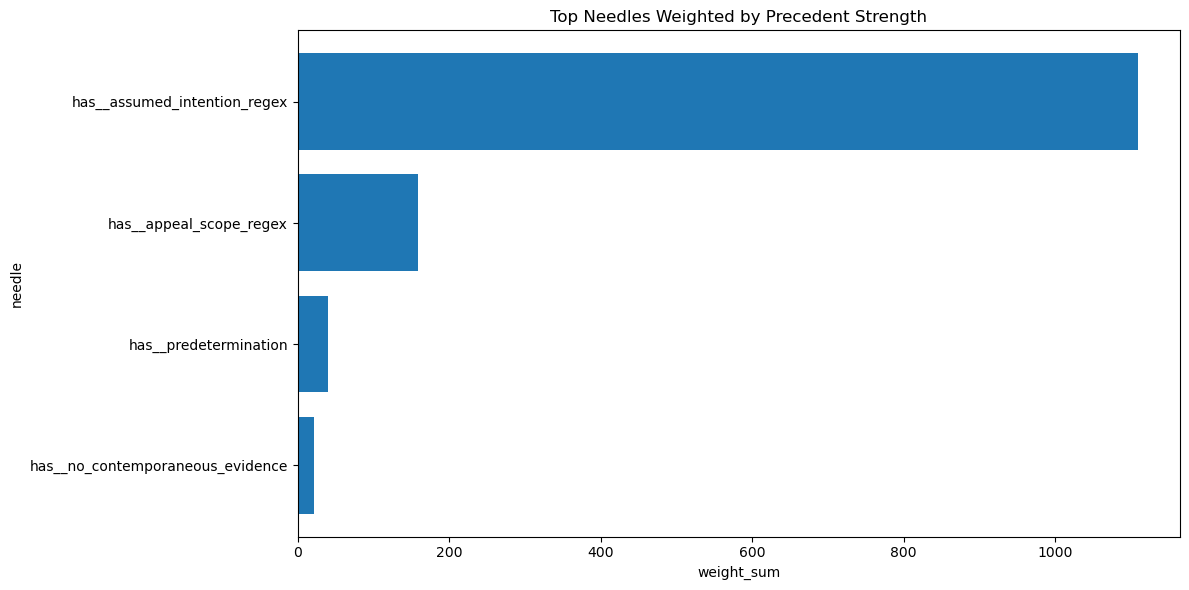

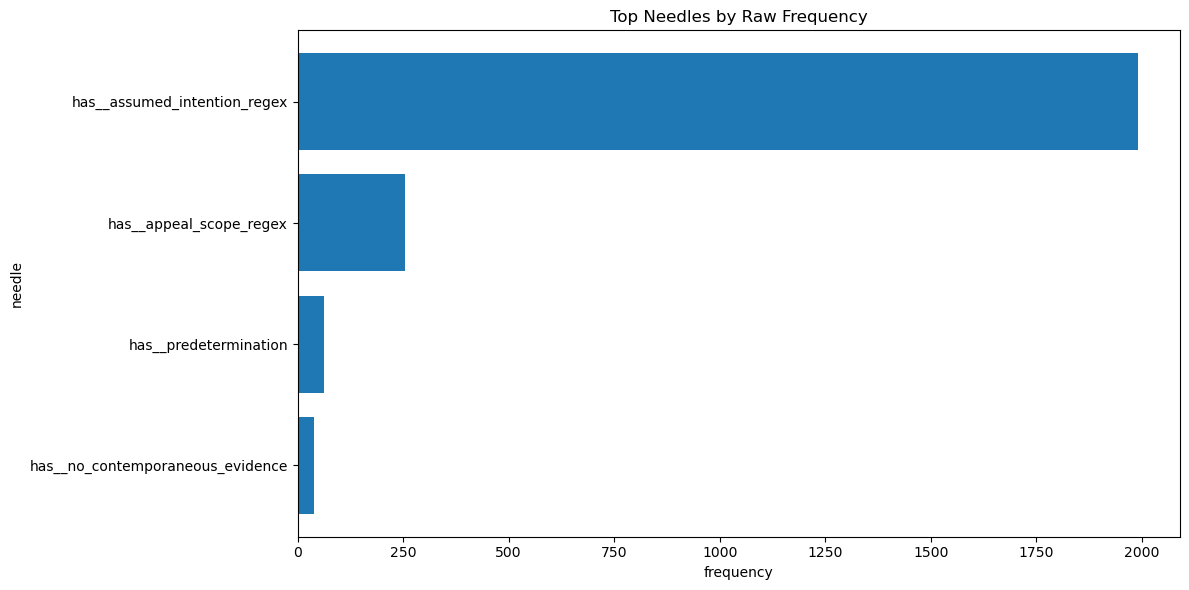

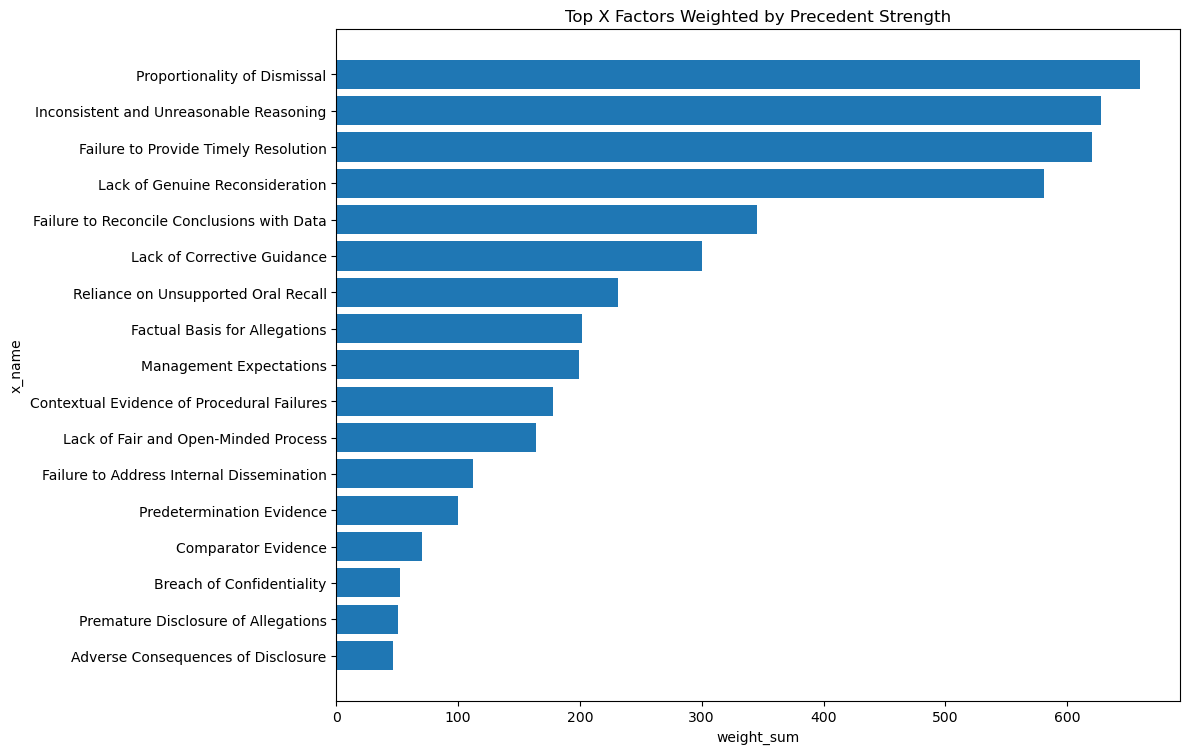

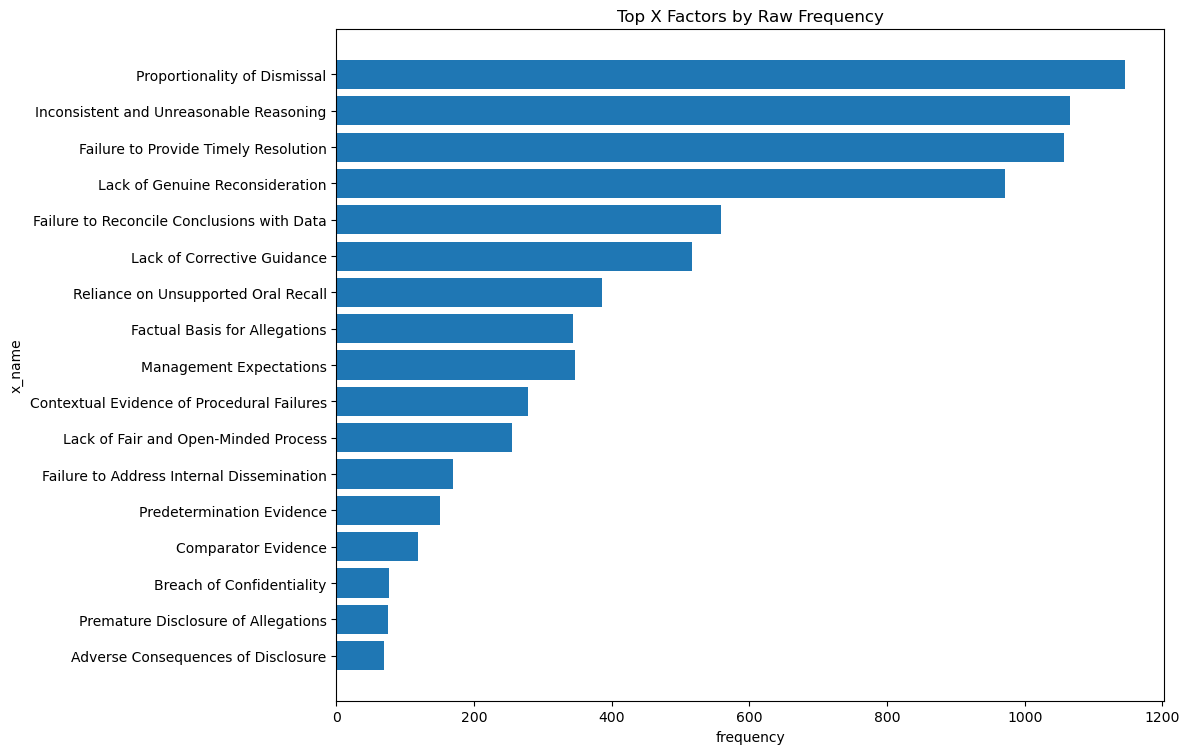


=== QUICK SIGNALS ===
[needle strongest] has__assumed_intention_regex | weight_sum=1109.1945, freq=1991, avg_strength=0.557104
[x strongest] Proportionality of Dismissal | weight_sum=659.7472, freq=1145, avg_strength=0.576198
[strongest edge] has__assumed_intention_regex -> Proportionality of Dismissal | edge_weight=654.1617


In [4]:
# =========================================================
# MOLTIE – Exploratory Needle/X Weighted Frequency Cell
# =========================================================
# Purpose:
#   - Dynamically explore matched_needles_pdf and x_name_pdf
#   - Track:
#       1) raw frequency
#       2) precedent-strength weighted sums
#       3) average precedent strength
#       4) case coverage
#       5) needle ↔ X weighted co-occurrence graph
#
# Notes:
#   - No static schema required
#   - Fully exploratory
#   - Safe against blanks / NaN / odd spacing
# =========================================================

from collections import defaultdict
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
CSV_PATH = Path("/home/hello/Projects/Statements/output/moltie_batch (Y10-Y12)/MASTER_moltie__pdf_frequency.csv")  # <-- adjust if needed
PRECEDENT_COL = "precedent_strength"
NEEDLE_COL = "matched_needles_pdf"
X_COL = "x_name_pdf"

# Optional identifier column for case coverage / provenance.
# If missing, row index will be used.
CASE_ID_CANDIDATES = [
    "case_id",
    "case_name",
    "filename",
    "pdf_name",
    "source_file",
    "document_id",
]

TOP_N = 20
SHOW_PLOTS = True

# =========================================================
# HELPERS
# =========================================================
def split_pipe_field(value):
    """
    Split a pipe-separated field into clean tokens.
    Handles NaN, blanks, duplicated separators, and whitespace.
    """
    if pd.isna(value):
        return []

    text = str(value).strip()
    if not text:
        return []

    parts = [p.strip() for p in text.split("|")]
    parts = [p for p in parts if p and p.lower() not in {"nan", "none", "null"}]
    return parts


def choose_case_id_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def build_stats_table(stats_dict, label_col):
    rows = []
    for key, payload in stats_dict.items():
        freq = payload["freq"]
        weight_sum = payload["weight_sum"]
        avg_strength = weight_sum / freq if freq else 0.0
        case_coverage = len(payload["cases"])

        rows.append({
            label_col: key,
            "frequency": freq,
            "weight_sum": round(weight_sum, 6),
            "avg_strength": round(avg_strength, 6),
            "case_coverage": case_coverage,
        })

    out = pd.DataFrame(rows)

    if not out.empty:
        out = out.sort_values(
            ["weight_sum", "frequency", "avg_strength"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

    return out


def build_graph_table(graph_dict, source_name="needle", target_name="x"):
    rows = []
    for src, targets in graph_dict.items():
        for tgt, weight in targets.items():
            rows.append({
                source_name: src,
                target_name: tgt,
                "edge_weight": round(weight, 6),
            })

    out = pd.DataFrame(rows)

    if not out.empty:
        # total raw edge mass by source and target
        source_totals = out.groupby(source_name)["edge_weight"].sum()
        target_totals = out.groupby(target_name)["edge_weight"].sum()

        # map totals back
        out["source_total_weight"] = out[source_name].map(source_totals)
        out["target_total_weight"] = out[target_name].map(target_totals)

        # cosine-style normalization
        out["edge_weight_norm"] = (
            out["edge_weight"] /
            np.sqrt(out["source_total_weight"] * out["target_total_weight"])
        ).round(6)

        out = out.sort_values(
            ["edge_weight_norm", "edge_weight"],
            ascending=[False, False]
        ).reset_index(drop=True)

    return out

def plot_top_barh(df_plot, label_col, value_col, title, top_n=20):
    if df_plot.empty:
        print(f"[warn] No data available for plot: {title}")
        return

    data = df_plot.head(top_n).iloc[::-1]  # reverse so strongest is on top visually
    plt.figure(figsize=(12, max(6, min(12, len(data) * 0.45))))
    plt.barh(data[label_col], data[value_col])
    plt.title(title)
    plt.xlabel(value_col)
    plt.ylabel(label_col)
    plt.tight_layout()
    plt.show()


# =========================================================
# LOAD
# =========================================================
df = pd.read_csv(CSV_PATH)

required_cols = [PRECEDENT_COL, NEEDLE_COL, X_COL]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

case_id_col = choose_case_id_column(df, CASE_ID_CANDIDATES)
if case_id_col is None:
    print("[info] No explicit case-id column found. Using row index as case identifier.")
    df["_row_case_id"] = df.index.astype(str)
    case_id_col = "_row_case_id"
else:
    print(f"[info] Using case identifier column: {case_id_col}")

# Pre-clean precedent strength
df[PRECEDENT_COL] = pd.to_numeric(df[PRECEDENT_COL], errors="coerce").fillna(0.0)

print(f"[info] Loaded rows: {len(df):,}")
print(f"[info] CSV path: {CSV_PATH}")

# =========================================================
# EXPLORATORY ACCUMULATORS
# =========================================================
needle_stats = defaultdict(lambda: {"freq": 0, "weight_sum": 0.0, "cases": set()})
x_stats = defaultdict(lambda: {"freq": 0, "weight_sum": 0.0, "cases": set()})

# Weighted co-occurrence graph: needle -> x
needle_x_graph = defaultdict(lambda: defaultdict(float))

# Optional reverse graph: x -> needle
x_needle_graph = defaultdict(lambda: defaultdict(float))

# =========================================================
# MAIN LOOP
# =========================================================
for _, row in df.iterrows():
    strength = float(row[PRECEDENT_COL])
    case_id = str(row[case_id_col])

    needles = split_pipe_field(row[NEEDLE_COL])
    xs = split_pipe_field(row[X_COL])

    # ---- Needle stats ----
    for needle in needles:
        needle_stats[needle]["freq"] += 1
        needle_stats[needle]["weight_sum"] += strength
        needle_stats[needle]["cases"].add(case_id)

    # ---- X stats ----
    for x_name in xs:
        x_stats[x_name]["freq"] += 1
        x_stats[x_name]["weight_sum"] += strength
        x_stats[x_name]["cases"].add(case_id)

    # ---- Needle ↔ X weighted graph ----
    if needles and xs:
        for needle in needles:
            for x_name in xs:
                needle_x_graph[needle][x_name] += strength
                x_needle_graph[x_name][needle] += strength

# =========================================================
# BUILD OUTPUT TABLES
# =========================================================
needle_table = build_stats_table(needle_stats, "needle")
x_table = build_stats_table(x_stats, "x_name")
needle_x_table = build_graph_table(needle_x_graph, "needle", "x_name")
x_needle_table = build_graph_table(x_needle_graph, "x_name", "needle")

# =========================================================
# OPTIONAL NORMALISED METRICS
# =========================================================
if not needle_table.empty:
    needle_table["weight_share"] = (needle_table["weight_sum"] / needle_table["weight_sum"].sum()).round(6)
    needle_table["freq_share"] = (needle_table["frequency"] / needle_table["frequency"].sum()).round(6)

if not x_table.empty:
    x_table["weight_share"] = (x_table["weight_sum"] / x_table["weight_sum"].sum()).round(6)
    x_table["freq_share"] = (x_table["frequency"] / x_table["frequency"].sum()).round(6)

# =========================================================
# DISPLAY
# =========================================================
print("\n=== TOP NEEDLES (weighted by precedent_strength) ===")
display(needle_table.head(TOP_N))

print("\n=== TOP X FACTORS (weighted by precedent_strength) ===")
display(x_table.head(TOP_N))

print("\n=== TOP NEEDLE -> X EDGES (weighted co-occurrence) ===")
display(needle_x_table.head(TOP_N))

# =========================================================
# PLOTS
# =========================================================
if SHOW_PLOTS:
    plot_top_barh(
        needle_table,
        label_col="needle",
        value_col="weight_sum",
        title="Top Needles Weighted by Precedent Strength",
        top_n=TOP_N,
    )

    plot_top_barh(
        needle_table,
        label_col="needle",
        value_col="frequency",
        title="Top Needles by Raw Frequency",
        top_n=TOP_N,
    )

    plot_top_barh(
        x_table,
        label_col="x_name",
        value_col="weight_sum",
        title="Top X Factors Weighted by Precedent Strength",
        top_n=TOP_N,
    )

    plot_top_barh(
        x_table,
        label_col="x_name",
        value_col="frequency",
        title="Top X Factors by Raw Frequency",
        top_n=TOP_N,
    )

# =========================================================
# QUICK INTERPRETATION HOOKS
# =========================================================
print("\n=== QUICK SIGNALS ===")

if not needle_table.empty:
    strongest_needle = needle_table.iloc[0]
    print(
        f"[needle strongest] {strongest_needle['needle']} | "
        f"weight_sum={strongest_needle['weight_sum']}, "
        f"freq={strongest_needle['frequency']}, "
        f"avg_strength={strongest_needle['avg_strength']}"
    )

if not x_table.empty:
    strongest_x = x_table.iloc[0]
    print(
        f"[x strongest] {strongest_x['x_name']} | "
        f"weight_sum={strongest_x['weight_sum']}, "
        f"freq={strongest_x['frequency']}, "
        f"avg_strength={strongest_x['avg_strength']}"
    )

if not needle_x_table.empty:
    strongest_edge = needle_x_table.iloc[0]
    print(
        f"[strongest edge] {strongest_edge['needle']} -> {strongest_edge['x_name']} | "
        f"edge_weight={strongest_edge['edge_weight']}"
    )

# =========================================================
# OPTIONAL SAVE
# =========================================================
# Uncomment if you want persistent outputs
#
# OUT_DIR = CSV_PATH.parent / "exploratory_outputs"
# OUT_DIR.mkdir(parents=True, exist_ok=True)
#
# needle_table.to_csv(OUT_DIR / "needle_weighted_distribution.csv", index=False)
# x_table.to_csv(OUT_DIR / "x_weighted_distribution.csv", index=False)
# needle_x_table.to_csv(OUT_DIR / "needle_x_weighted_edges.csv", index=False)
# x_needle_table.to_csv(OUT_DIR / "x_needle_weighted_edges.csv", index=False)
#
# print(f"\n[info] Saved exploratory outputs to: {OUT_DIR}")

In [5]:
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
import re
import fitz
import csv
from tqdm import tqdm

ROOT = Path("/media/hello/Vault/Tribunals")
OUT_CSV = ROOT / "bloomberg_pdf_hits.csv"

PATTERN = re.compile(
    r"\bbloomberg(?:\s+l\.?\s*p\.?)?\b",
    re.IGNORECASE
)

def scan_pdf(pdf_path: Path):
    try:
        doc = fitz.open(pdf_path)
        hit_pages = []

        for page_num in range(len(doc)):
            text = doc.load_page(page_num).get_text("text")
            if text and PATTERN.search(text):
                hit_pages.append(page_num + 1)

        doc.close()

        if hit_pages:
            return {
                "file_path": str(pdf_path),
                "hit_pages": ",".join(map(str, hit_pages)),
                "n_hit_pages": len(hit_pages),
            }

    except Exception as e:
        return {
            "file_path": str(pdf_path),
            "hit_pages": "",
            "n_hit_pages": "",
            "error": str(e)[:300],
        }

    return None


def main():

    pdf_files = list(ROOT.rglob("*.pdf"))
    print(f"\nPDF files found: {len(pdf_files):,}")

    workers = max(1, mp.cpu_count() - 2)
    print(f"Using {workers} CPU workers\n")

    rows = []

    with ProcessPoolExecutor(max_workers=workers) as executor:

        futures = [executor.submit(scan_pdf, pdf) for pdf in pdf_files]

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="Scanning PDFs",
            unit="pdf"
        ):

            result = future.result()

            if result:
                rows.append(result)

    fieldnames = ["file_path", "hit_pages", "n_hit_pages", "error"]

    with open(OUT_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print("\nDone.")
    print(f"Matches found: {len(rows)}")
    print(f"Saved to: {OUT_CSV}")


if __name__ == "__main__":
    main()


PDF files found: 0
Using 46 CPU workers



Scanning PDFs: 0pdf [00:00, ?pdf/s]


FileNotFoundError: [Errno 2] No such file or directory: '/media/hello/Vault/Tribunals/bloomberg_pdf_hits.csv'